# 1. Perkenalan Dataset

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:
# 1. Sumber Dataset:  
     Sumber Dataset:
     Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (Kaggle, UCI ML Repository, Open Data) atau data primer yang Anda kumpulkan sendiri.

In [ ]:
!pip install -q mlflow==2.22.0

# 2. Import Library

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
# 2. IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import mlflow
import mlflow.sklearn

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Semua library berhasil diimport!")
print(f"Pandas version: {pd.__version__}")
print(f"Sklearn version: {sklearn.__version__}")
print(f"MLflow version: {mlflow.__version__}")

✅ Semua library berhasil diimport!
Pandas version: 2.3.3
Sklearn version: 1.9.0
MLflow version: 3.14.0


# 3. Memuat Dataset

In [ ]:
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# 3. MEMUAT DATASET
df = pd.read_csv('/home/iman/Eksperimen_SML_ImanRohiman/preprocessing/namadataset_preprocessing/titanic_preprocessing.csv')
# df = pd.read_csv('../namadataset_raw/titanic.csv')

# Tampilkan informasi awal
print("="*60)
print("📊 INFORMASI DATASET")
print("="*60)

print(f"\n✅ Dataset berhasil dimuat!")
print(f"📊 Jumlah baris: {df.shape[0]}")
print(f"📊 Jumlah kolom: {df.shape[1]}")

print("\n📋 5 Data Pertama:")
display(df.head())

print("\n📋 Informasi Dataset:")
df.info()

print("\n📊 Statistik Deskriptif:")
df.describe()

📊 INFORMASI DATASET

✅ Dataset berhasil dimuat!
📊 Jumlah baris: 891
📊 Jumlah kolom: 8

📋 5 Data Pertama:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,-0.565736,1,0,-0.502445,2
1,1,1,0,0.663861,1,0,0.786845,0
2,1,3,0,-0.258337,0,0,-0.488854,2
3,1,1,0,0.433312,1,0,0.420730,2
4,0,3,1,0.433312,0,0,-0.486337,2



📋 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB

📊 Statistik Deskriptif:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891.000000,8.910000e+02,891.000000,891.000000,8.910000e+02,891.000000
mean,0.383838,2.308642,0.647587,2.392400e-16,0.523008,0.381594,2.791133e-17,1.536476
std,0.486592,0.836071,0.477990,1.000562e+00,1.102743,0.806057,1.000562e+00,0.791503
min,0.000000,1.000000,0.000000,-2.224156e+00,0.000000,0.000000,-6.484217e-01,0.000000
25%,0.000000,2.000000,0.000000,-5.657365e-01,0.000000,0.000000,-4.891482e-01,1.000000
50%,0.000000,3.000000,1.000000,-1.046374e-01,0.000000,0.000000,-3.573909e-01,2.000000
75%,1.000000,3.000000,1.000000,4.333115e-01,1.000000,0.000000,-2.424635e-02,2.000000
max,1.000000,3.000000,1.000000,3.891554e+00,8.000000,6.000000,9.667167e+00,2.000000


# 4. Exploratory Data Analysis (EDA)

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

📊 EXPLORATORY DATA ANALYSIS (EDA)

🔍 4.1. Missing Values:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

🎯 4.2. Distribusi Target (Survived):
Survived
0    549
1    342
Name: count, dtype: int64

Persentase Selamat: 38.38%
Persentase Tidak Selamat: 61.62%


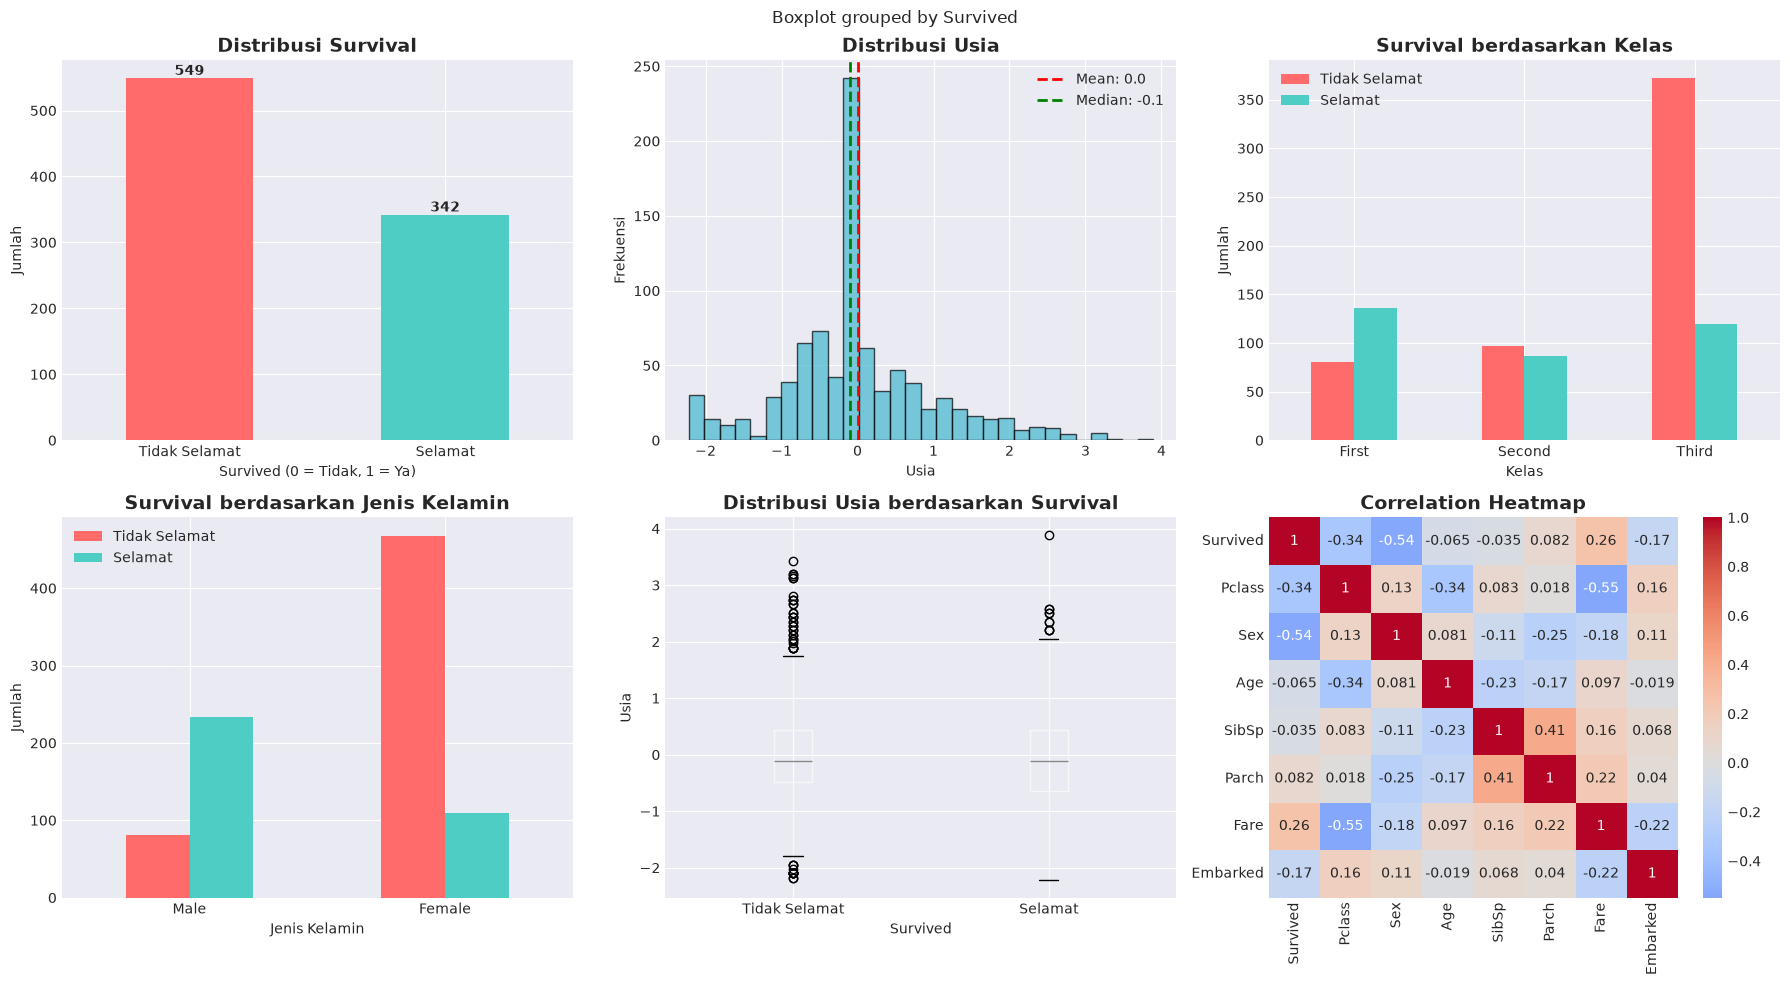


💡 INSIGHT DARI EDA:
1. Dataset memiliki missing values pada kolom Age, Cabin, dan Embarked
2. Target tidak seimbang (hanya ~38% yang selamat)
3. Penumpang wanita memiliki tingkat survival lebih tinggi
4. Penumpang kelas 1 memiliki tingkat survival lebih tinggi
5. Usia memiliki korelasi negatif dengan survival (lebih muda cenderung selamat)
6. Fare memiliki korelasi positif dengan survival (harga tiket tinggi = peluang selamat lebih tinggi)


In [3]:
# 4. EXPLORATORY DATA ANALYSIS (EDA)
print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# 4.1. Cek Missing Values
print("\n🔍 4.1. Missing Values:")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Values'] > 0])

# 4.2. Distribusi Target
print("\n🎯 4.2. Distribusi Target (Survived):")
survived_counts = df['Survived'].value_counts()
print(survived_counts)
print(f"\nPersentase Selamat: {df['Survived'].mean()*100:.2f}%")
print(f"Persentase Tidak Selamat: {(1 - df['Survived'].mean())*100:.2f}%")

# 4.3. Visualisasi EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Distribusi Survival
colors = ['#FF6B6B', '#4ECDC4']
survived_counts.plot(kind='bar', ax=axes[0,0], color=colors)
axes[0,0].set_title('Distribusi Survival', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Survived (0 = Tidak, 1 = Ya)')
axes[0,0].set_ylabel('Jumlah')
axes[0,0].set_xticklabels(['Tidak Selamat', 'Selamat'], rotation=0)
for i, v in enumerate(survived_counts.values):
    axes[0,0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2: Distribusi Usia
axes[0,1].hist(df['Age'].dropna(), bins=30, color='#45B7D1', edgecolor='black', alpha=0.7)
axes[0,1].axvline(df['Age'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
axes[0,1].axvline(df['Age'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {df["Age"].median():.1f}')
axes[0,1].set_title('Distribusi Usia', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Usia')
axes[0,1].set_ylabel('Frekuensi')
axes[0,1].legend()

# Plot 3: Survival berdasarkan Kelas
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar', ax=axes[0,2], color=colors, stacked=False)
axes[0,2].set_title('Survival berdasarkan Kelas', fontsize=14, fontweight='bold')
axes[0,2].set_xlabel('Kelas')
axes[0,2].set_ylabel('Jumlah')
axes[0,2].legend(['Tidak Selamat', 'Selamat'])
axes[0,2].set_xticklabels(['First', 'Second', 'Third'], rotation=0)

# Plot 4: Survival berdasarkan Jenis Kelamin
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', ax=axes[1,0], color=colors, stacked=False)
axes[1,0].set_title('Survival berdasarkan Jenis Kelamin', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Jenis Kelamin')
axes[1,0].set_ylabel('Jumlah')
axes[1,0].legend(['Tidak Selamat', 'Selamat'])
axes[1,0].set_xticklabels(['Male', 'Female'], rotation=0)

# Plot 5: Boxplot Usia vs Survival
df.boxplot(column='Age', by='Survived', ax=axes[1,1])
axes[1,1].set_title('Distribusi Usia berdasarkan Survival', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Survived')
axes[1,1].set_ylabel('Usia')
axes[1,1].set_xticklabels(['Tidak Selamat', 'Selamat'])

# Plot 6: Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 4.4. Insight dari EDA
print("\n💡 INSIGHT DARI EDA:")
print("1. Dataset memiliki missing values pada kolom Age, Cabin, dan Embarked")
print("2. Target tidak seimbang (hanya ~38% yang selamat)")
print("3. Penumpang wanita memiliki tingkat survival lebih tinggi")
print("4. Penumpang kelas 1 memiliki tingkat survival lebih tinggi")
print("5. Usia memiliki korelasi negatif dengan survival (lebih muda cenderung selamat)")
print("6. Fare memiliki korelasi positif dengan survival (harga tiket tinggi = peluang selamat lebih tinggi)")

# 5. Data Preprocessing

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi tidak terbatas pada:

Menghapus atau Menangani Data Kosong (Missing Values)
Menghapus Data Duplikat
Normalisasi atau Standarisasi Fitur
Deteksi dan Penanganan Outlier
Encoding Data Kategorikal
Binning (Pengelompokan Data)
Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 5. DATA PREPROCESSING
print("="*60)
print("🔄 DATA PREPROCESSING")
print("="*60)

# Copy data untuk preprocessing
df_processed = df.copy()

# 5.1. Cek kolom yang ada
print("\n📌 5.1. Cek kolom yang tersedia:")
print(f"Kolom: {df_processed.columns.tolist()}")

# 5.2. Drop kolom yang tidak diperlukan (jika ada)
print("\n📌 5.2. Drop kolom yang tidak diperlukan:")
drop_cols = []
for col in ['PassengerId', 'Name', 'Ticket', 'Cabin']:
    if col in df_processed.columns:
        drop_cols.append(col)

if drop_cols:
    df_processed = df_processed.drop(columns=drop_cols)
    print(f"✅ Kolom yang di-drop: {drop_cols}")
else:
    print(f"⚠️ Tidak ada kolom yang perlu di-drop")
print(f"✅ Shape setelah drop: {df_processed.shape}")

# 5.3. Handle Missing Values
print("\n📌 5.3. Handle Missing Values:")
print(f"Missing values sebelum: {df_processed.isnull().sum().sum()}")

# Cek kolom yang ada missing values
missing_cols = df_processed.columns[df_processed.isnull().any()].tolist()
print(f"Kolom dengan missing values: {missing_cols}")

# Age - diisi dengan median (jika ada)
if 'Age' in df_processed.columns:
    df_processed['Age'] = df_processed['Age'].fillna(df_processed['Age'].median())
    print(f"✅ Age: diisi dengan median ({df_processed['Age'].median():.1f})")

# Embarked - diisi dengan modus (jika ada)
if 'Embarked' in df_processed.columns:
    df_processed['Embarked'] = df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0])
    print(f"✅ Embarked: diisi dengan modus ('{df_processed['Embarked'].mode()[0]}')")

# Cabin - drop jika terlalu banyak missing (jika ada)
if 'Cabin' in df_processed.columns:
    df_processed = df_processed.drop('Cabin', axis=1)
    print(f"✅ Cabin: di-drop karena banyak missing")

print(f"Missing values setelah: {df_processed.isnull().sum().sum()}")

# 5.4. Encode Categorical Variables
print("\n📌 5.4. Encode Categorical Variables:")

# Cek kolom kategorikal
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom kategorikal: {categorical_cols}")

for col in categorical_cols:
    if col != 'Survived':  # Target tidak perlu di-encode
        df_processed[col] = LabelEncoder().fit_transform(df_processed[col])
        print(f"✅ {col}: sudah di-encode")

# 5.5. Feature Scaling
print("\n📌 5.5. Feature Scaling (StandardScaler):")

# Cek kolom numerik untuk scaling
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
# Exclude target dan kolom yang sudah binary
cols_to_scale = []
for col in numeric_cols:
    if col != 'Survived' and len(df_processed[col].unique()) > 2:
        cols_to_scale.append(col)

if cols_to_scale:
    scaler = StandardScaler()
    df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])
    print(f"✅ Kolom yang di-scale: {cols_to_scale}")
else:
    print(f"⚠️ Tidak ada kolom yang perlu di-scale")

# 5.6. Cek hasil preprocessing
print("\n📋 Data setelah preprocessing:")
display(df_processed.head())

print("\n📊 Statistik setelah preprocessing:")
display(df_processed.describe())

# ★★★ WAJIB: Simpan data yang sudah dipreprocess ★★★
df_processed.to_csv('titanic_preprocessing.csv', index=False)
print("\n💾 Data preprocessing completed and saved to: titanic_preprocessing.csv")
print(f"📊 Shape data tersimpan: {df_processed.shape}")

🔄 DATA PREPROCESSING

📌 5.1. Cek kolom yang tersedia:
Kolom: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

📌 5.2. Drop kolom yang tidak diperlukan:
⚠️ Tidak ada kolom yang perlu di-drop
✅ Shape setelah drop: (891, 8)

📌 5.3. Handle Missing Values:
Missing values sebelum: 0
Kolom dengan missing values: []
✅ Age: diisi dengan median (-0.1)
✅ Embarked: diisi dengan modus ('2')
Missing values setelah: 0

📌 5.4. Encode Categorical Variables:
Kolom kategorikal: []

📌 5.5. Feature Scaling (StandardScaler):
✅ Kolom yang di-scale: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

📋 Data setelah preprocessing:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,0.827377,1,-0.565736,0.432793,-0.473674,-0.502445,0.585954
1,1,-1.566107,0,0.663861,0.432793,-0.473674,0.786845,-1.942303
2,1,0.827377,0,-0.258337,-0.474545,-0.473674,-0.488854,0.585954
3,1,-1.566107,0,0.433312,0.432793,-0.473674,0.420730,0.585954
4,0,0.827377,1,0.433312,-0.474545,-0.473674,-0.486337,0.585954



📊 Statistik setelah preprocessing:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,8.910000e+02,891.000000,8.910000e+02,8.910000e+02,8.910000e+02,8.910000e+02,8.910000e+02
mean,0.383838,-8.772133e-17,0.647587,-2.791133e-17,4.386066e-17,5.382900e-17,-7.974666e-18,-4.984166e-17
std,0.486592,1.000562e+00,0.477990,1.000562e+00,1.000562e+00,1.000562e+00,1.000562e+00,1.000562e+00
min,0.000000,-1.566107e+00,0.000000,-2.224156e+00,-4.745452e-01,-4.736736e-01,-6.484217e-01,-1.942303e+00
25%,0.000000,-3.693648e-01,0.000000,-5.657365e-01,-4.745452e-01,-4.736736e-01,-4.891482e-01,-6.781745e-01
50%,0.000000,8.273772e-01,1.000000,-1.046374e-01,-4.745452e-01,-4.736736e-01,-3.573909e-01,5.859541e-01
75%,1.000000,8.273772e-01,1.000000,4.333115e-01,4.327934e-01,-4.736736e-01,-2.424635e-02,5.859541e-01
max,1.000000,8.273772e-01,1.000000,3.891554e+00,6.784163e+00,6.974147e+00,9.667167e+00,5.859541e-01



💾 Data preprocessing completed and saved to: titanic_preprocessing.csv
📊 Shape data tersimpan: (891, 8)
